Saving Copy of my version compton scattering analysis Q3 - Sheet1.csv to Copy of my version compton scattering analysis Q3 - Sheet1 (3).csv
File uploaded: Copy of my version compton scattering analysis Q3 - Sheet1 (3).csv
Columns in the file: ['Channel', 'background', '137Cs_small_Al_ 25degrees', '137Cs_small_Cu_ 25degrees', '137Cs_small_Al_ 45degrees', '137Cs_small_Cu_ 45degrees', ' subtracting background----->', 'Unnamed: 7', 'Channel.1', '137Cs_small_Al_ 25degrees.1', '137Cs_small_Cu_ 25degrees.1', '137Cs_small_Al_ 45degrees.1', '137Cs_small_Cu_ 45degrees.1', '-------> only photopeak part', 'Unnamed: 14', 'Channel_photopeak', '137Cs_small_Al_ 25deg_photopeak', 'Unnamed: 17', '137Cs_small_Al_ 45deg_photopeak', 'Unnamed: 19', '137Cs_small_Cu_ 25deg_photopeak', 'Unnamed: 21', '137Cs_small_Cu_ 45deg_photopeak', 'Unnamed: 23', 'scatterer', 'theta (degrees)', 'Y(theta)']


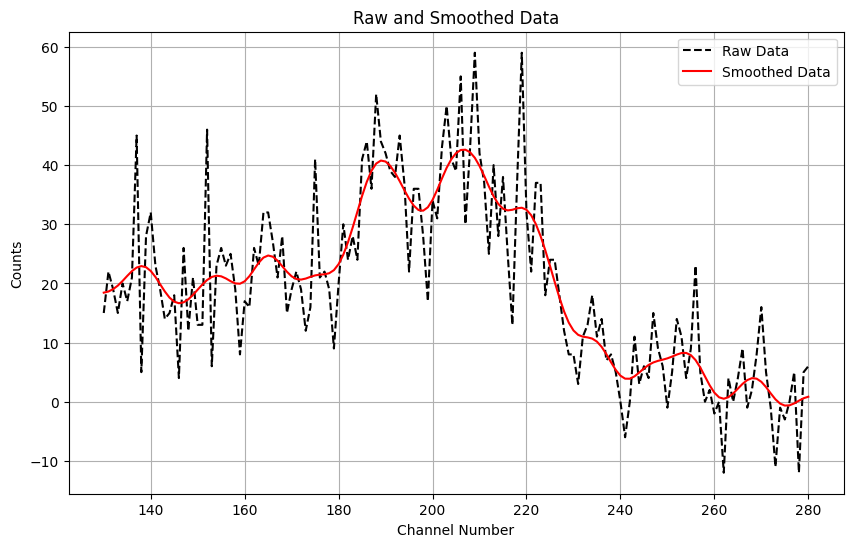

Fitted parameters:
  A (Amplitude) = 29.2321 ± 0.7368
  B (Slope) = -0.1484 ± 0.0062
  Sigma (Width) = 17.5197 ± 0.5822
  x_bar (Center) = 203.3063 ± 0.5042
  C (Offset) = 41.4870 ± 1.3495
  Area under the Gaussian curve (analytical) = 1283.7392 ± 53.5441
  Area under the Gaussian curve (numerical) = 1283.7131 ± 0.0000


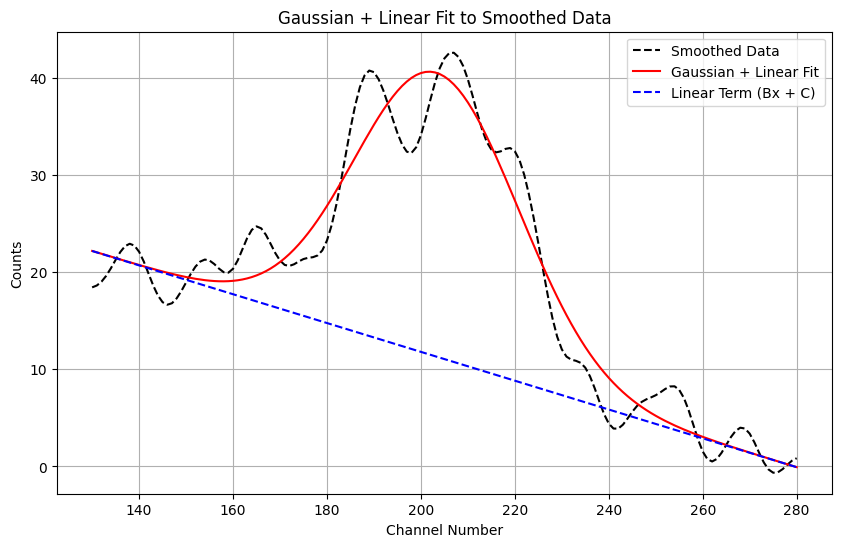

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter1d  # For smoothing
from scipy.integrate import quad  # For numerical integration
import pandas as pd
from google.colab import files

# Define the Gaussian function with a linear term
def gaussian_with_linear(x, A, B, sigma, x_bar, C):
    return A * np.exp(-((x - x_bar) ** 2) / (2 * sigma ** 2)) + B * x + C

# Read data from CSV file
def read_data():
    try:
        # Prompt user to upload the file
        uploaded = files.upload()

        # Read the first uploaded file (you can select it manually)
        for filename in uploaded.keys():
            print(f"File uploaded: {filename}")
            # Read the CSV file into a pandas DataFrame
            data = pd.read_csv(filename)

            # Print out the column names to check
            print(f"Columns in the file: {data.columns.tolist()}")
            # Update the column names based on your data file
            #--------------------------------------------------------------------------------------------------------------------------------------column names
            channel_number = data['Channel_photopeak'].to_numpy()
            counts = data['137Cs_small_Cu_ 45deg_photopeak'].to_numpy()

            return channel_number, counts
    except Exception as e:
        print(f"Error reading file: {e}")
        return None, None

# Filter out NaN and Inf values from the data
def clean_data(channel_number, counts):
    mask = np.isfinite(channel_number) & np.isfinite(counts)
    return channel_number[mask], counts[mask]

# Apply smoothing to reduce noise
def smooth_data(counts, sigma=3):
    return gaussian_filter1d(counts, sigma=sigma)

# Load the data from the file
channel_number, counts = read_data()

if channel_number is not None and counts is not None:
    # Clean the data (remove NaNs or Inf values)
    channel_number, counts = clean_data(channel_number, counts)

    # Check if the data is empty after cleaning
    if len(channel_number) == 0 or len(counts) == 0:
        print("Data contains only NaNs or Infs after cleaning. Please check your file.")
    else:
        # Apply smoothing to the counts data
        smoothed_counts = smooth_data(counts, sigma=3)

        # Plot the raw and smoothed data to inspect the effect of smoothing
        plt.figure(figsize=(10, 6))
        plt.plot(channel_number, counts, 'k--', label='Raw Data')
        plt.plot(channel_number, smoothed_counts, 'r-', label='Smoothed Data')
        plt.xlabel('Channel Number')
        plt.ylabel('Counts')
        plt.title('Raw and Smoothed Data')
        plt.legend()
        plt.grid(True)
        plt.show()

        # Improved initial guess for Gaussian + Linear fit
        A_guess = max(smoothed_counts)
        sigma_guess = 10
        x_bar_guess = channel_number[np.argmax(smoothed_counts)]
        B_guess = 0
        C_guess = min(smoothed_counts)

        initial_guess = [A_guess, B_guess, sigma_guess, x_bar_guess, C_guess]

        # Define bounds for the parameters to avoid unrealistic values
        bounds = ([-np.inf, -np.inf, 1, x_bar_guess - 5, -np.inf],
                  [np.inf, np.inf, 50, x_bar_guess + 5, np.inf])

        try:
            # Fit the Gaussian + Linear function to the smoothed data with bounds
            popt, pcov = curve_fit(gaussian_with_linear, channel_number, smoothed_counts,
                                   p0=initial_guess, bounds=bounds, maxfev=5000)

            # Extract fitted parameters
            A_fit, B_fit, sigma_fit, x_bar_fit, C_fit = popt
            A_error, B_error, sigma_error, x_bar_error, C_error = np.sqrt(np.diag(pcov))

            # Analytical calculation of the area under the Gaussian curve
            area_analytical = A_fit * sigma_fit * np.sqrt(2 * np.pi)

            # Error propagation for the area
            area_error_propagated = np.sqrt(
                (sigma_fit * np.sqrt(2 * np.pi) * A_error) ** 2 +
                (A_fit * np.sqrt(2 * np.pi) * sigma_error) ** 2
            )

            # Numerical integration to calculate the area under the Gaussian term
            def gaussian_without_linear(x):
                return A_fit * np.exp(-((x - x_bar_fit) ** 2) / (2 * sigma_fit ** 2))

            area_numerical, area_numerical_error = quad(gaussian_without_linear, min(channel_number), max(channel_number))

            # Print the fitted parameters with their errors
            print(f"Fitted parameters:")
            print(f"  A (Amplitude) = {A_fit:.4f} ± {A_error:.4f}")
            print(f"  B (Slope) = {B_fit:.4f} ± {B_error:.4f}")
            print(f"  Sigma (Width) = {sigma_fit:.4f} ± {sigma_error:.4f}")
            print(f"  x_bar (Center) = {x_bar_fit:.4f} ± {x_bar_error:.4f}")
            print(f"  C (Offset) = {C_fit:.4f} ± {C_error:.4f}")
            print(f"  Area under the Gaussian curve (analytical) = {area_analytical:.4f} ± {area_error_propagated:.4f}")
            print(f"  Area under the Gaussian curve (numerical) = {area_numerical:.4f} ± {area_numerical_error:.4f}")

            # Plotting the results
            plt.figure(figsize=(10, 6))
            plt.plot(channel_number, smoothed_counts, 'k--', label='Smoothed Data')
            plt.plot(channel_number, gaussian_with_linear(channel_number, *popt), 'r-', label='Gaussian + Linear Fit')

            # Plot the individual linear term
            linear_line = B_fit * channel_number + C_fit
            plt.plot(channel_number, linear_line, 'b--', label='Linear Term (Bx + C)')

            plt.xlabel('Channel Number')
            plt.ylabel('Counts')
            plt.title('Gaussian + Linear Fit to Smoothed Data')
            plt.legend()
            plt.grid(True)
            plt.savefig("Gaussian_Linear_Fit.png")
            plt.show()

        except Exception as e:
            print("An error occurred during curve fitting:", e)
else:
    print("Could not load data. Please check the input file.")